## 条件概率与贝叶斯公式

# 标准贝叶斯公式：
$$
P(A|B) = \frac{P(B|A)P(A)}{P(B)}
$$

# 带入全概率公式：
$$
P(A|B) = \frac{P(B|A)P(A)}{P(B|A)P(A)+P(B|\overline{A})P(\overline{A})}
$$

1. np.random.choice(a,size=None,p=None): p: 每个元素被选中的概率，必须和为1

2. plt.scatter(): 控制大小的参数是s,不是 size 

检测为阳性时，真正患病的概率： 0.16666666666666669
不知道有没有病，去检测是阳的概率为: 0.0594


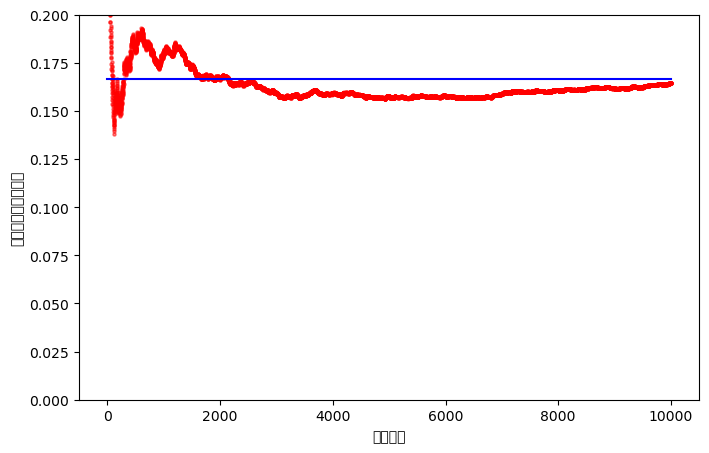

In [20]:
import numpy as np
import matplotlib.pyplot as plt
#例子；疾病检测问题
#某种疾病的患病率为1%
disease_prob=0.01
# 有病时检测为阳性的概率
disease_have_yang=0.99
# 无病时检测为阳性的概率
disease_havenot_yang=0.05
# 无病的概率为
disease_havenot=0.99
# 检测为阳，真正患病的概率
yang_have_disease=(disease_prob*disease_have_yang)/(disease_prob*disease_have_yang+disease_havenot*disease_havenot_yang)
p_yang=disease_prob*disease_have_yang+disease_havenot*disease_havenot_yang
print("检测为阳性时，真正患病的概率：",yang_have_disease)
print("不知道有没有病，去检测是阳的概率为:",p_yang)#不知道有没有病，去检测是阳的概率为0.0594
# 检查结果为阳且真正患病是1，结果为阳但无病0
result=[0,1]
p_result=[0.833,0.167]
# 统计“检查为阳性的人中真正患病的比例”
n=10000
freq_list=[]
count=0
for i in range(1,n+1):
    practise_y=np.random.choice(result,p=p_result)
    if practise_y==1:
        count+=1
    freq=count/i
    freq_list.append(freq)

#绘图
theorical_values=yang_have_disease
plt.figure(figsize=(8,5))
plt.plot([0,times],[theorical_values,theorical_values],c='b')
plt.scatter(range(1,n+1),freq_list,c='r',s=5,alpha=0.5)
plt.ylim(0,0.2)
plt.xlabel('模拟次数')
plt.ylabel('阳性人群中患病比例')
plt.show()



## 用蒙特卡洛模拟验证贝叶斯定理

1. np.random.random(n) : 会生成n个0~1之间的随机数

2. 用 < p_disease 判断 ： 如果随机数小于0.01，就标记为True（患病），否则为False（健康）

3. 最终 disease 是一个长度为 10000 的布尔数组，记录了每个人的真实患病状态

4. np.zeros() 的核心作用是生成一个全为 0 的数组，而它的元素类型可以指定的：

   · 不指定 dtype是，默认是 float64 类型，生成的是 [0.,0.,0.,......,0.]
   · 当指定 dtype=bool 时，会生成布尔值类型的数组，而数字 0 在布尔类型中会被自动解释为False

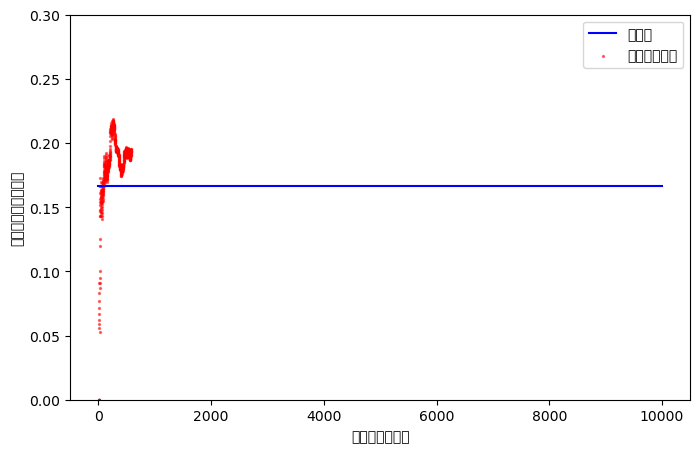

理论后验概率: 0.1667
模拟最终比例: 0.1938


In [18]:
import numpy as np
import matplotlib.pyplot as plt

# 参数
n = 10000
p_disease = 0.01
p_pos_given_disease = 0.99
p_pos_given_healthy = 0.05

# 1. 生成真实患病情况
disease = np.random.random(n) < p_disease

# 2. 生成检测结果
positive = np.zeros(n, dtype=bool)#默认所有人都是阴性（False）
for i in range(n):
    if disease[i]:
        positive[i] = np.random.random() < p_pos_given_disease
    else:
        positive[i] = np.random.random() < p_pos_given_healthy

# 3. 动态计算“阳性人群中患病比例”随样本量增加的变化
freq_list = []
count_pos_and_disease = 0
count_pos = 0

for i in range(n):
    if positive[i]:
        count_pos += 1
        if disease[i]:
            count_pos_and_disease += 1
        freq = count_pos_and_disease / count_pos if count_pos > 0 else 0
        freq_list.append(freq)

# 理论值
theoretical = (p_disease * p_pos_given_disease) / (
    p_disease * p_pos_given_disease + (1-p_disease) * p_pos_given_healthy
)

# 绘图
plt.figure(figsize=(8,5))
plt.plot([0, n], [theoretical, theoretical], 'b-', label='理论值')
plt.scatter(range(1, len(freq_list)+1), freq_list, c='r', s=2, alpha=0.5, label='模拟累积比例')
plt.xlabel('检测阳性的人数')
plt.ylabel('阳性人群中患病比例')
plt.legend()
plt.ylim(0, 0.3)
plt.show()

print(f"理论后验概率: {theoretical:.4f}")
print(f"模拟最终比例: {freq_list[-1]:.4f}")